# Training

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r'C:\Users\Arias\Downloads\LLMs\LLMs Project\Laboratorio-Dry-Bean-ML#\data\processed\dry_beans_clean.csv')
df.head()

X = df.drop(columns="Class")
y = df["Class"]

# Diagnóstico
print(f"Tipo de y: {y.dtype}")
print(f"Valores únicos en y: {y.unique()}")
print(f"Valores nulos: {y.isnull().sum()}")

Tipo de y: object
Valores únicos en y: ['SEKER' 'BARBUNYA' 'BOMBAY' 'CALI' 'HOROZ' 'SIRA' 'DERMASON']
Valores nulos: 0


# Entrenamiento - Modelo Baseline

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,
test_size=0.2,
random_state=42,
stratify=y
)

In [3]:
from sklearn.preprocessing import LabelEncoder

# Convertir valores categóricos a números
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_train_encoded = le.transform(y_train)
y_test_encoded = le.transform(y_test)

print(f"Clases mapeadas: {dict(zip(le.classes_, range(len(le.classes_))))}")
print(f"Tipo después del encoding: {type(y_train_encoded[0])}")

Clases mapeadas: {'BARBUNYA': 0, 'BOMBAY': 1, 'CALI': 2, 'DERMASON': 3, 'HOROZ': 4, 'SEKER': 5, 'SIRA': 6}
Tipo después del encoding: <class 'numpy.int64'>


In [4]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt

baseline_model = Pipeline(steps=[
("scaler", StandardScaler()),
("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
baseline_model.fit(X_train, y_train_encoded)

y_pred_baseline = baseline_model.predict(X_test)
accuracy_baseline = accuracy_score(y_test_encoded, y_pred_baseline)
f1_baseline = f1_score(y_test_encoded, y_pred_baseline, average="macro")
print("Accuracy baseline:", accuracy_baseline)
print("F1 macro baseline:", f1_baseline)
print(classification_report(y_test_encoded, y_pred_baseline))

Accuracy baseline: 0.9191583610188261
F1 macro baseline: 0.9302365421734592
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       265
           1       1.00      1.00      1.00       104
           2       0.91      0.94      0.93       326
           3       0.93      0.91      0.92       709
           4       0.96      0.94      0.95       372
           5       0.93      0.94      0.94       406
           6       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



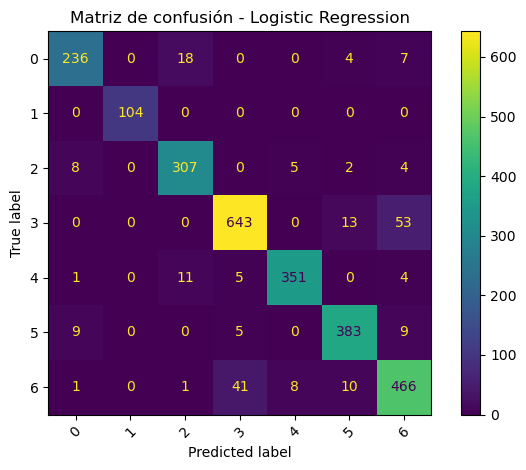

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test_encoded,
y_pred_baseline,
xticks_rotation=45
)
plt.title("Matriz de confusión - Logistic Regression")
plt.tight_layout()
plt.show()

## Entrenamiento - Random Forest

In [6]:
from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
n_estimators=200,
random_state=42,
class_weight="balanced"
)
forest_model.fit(X_train, y_train_encoded)

y_pred_forest = forest_model.predict(X_test)
accuracy_forest = accuracy_score(y_test_encoded, y_pred_forest)
f1_forest = f1_score(y_test_encoded, y_pred_forest, average="macro")
print("Accuracy Random Forest:", accuracy_forest)
print("F1 macro Random Forest:", f1_forest)
print(classification_report(y_test_encoded, y_pred_forest))

Accuracy Random Forest: 0.9191583610188261
F1 macro Random Forest: 0.9303396642494651
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       265
           1       1.00      1.00      1.00       104
           2       0.92      0.94      0.93       326
           3       0.91      0.92      0.92       709
           4       0.96      0.95      0.95       372
           5       0.95      0.95      0.95       406
           6       0.87      0.86      0.86       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



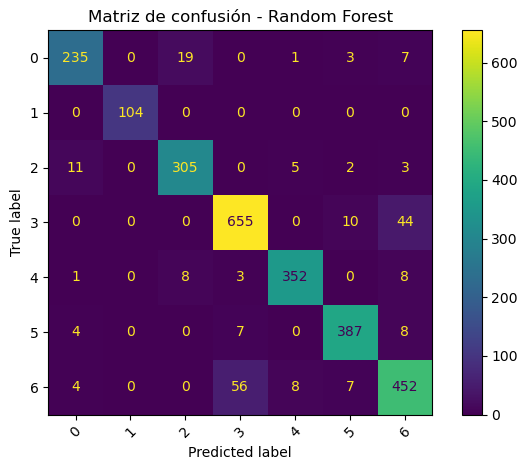

In [7]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
y_test_encoded,
y_pred_forest,
xticks_rotation=45
)
plt.title("Matriz de confusión - Random Forest")
plt.tight_layout()
plt.show()

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Solo transform, nunca fit en test

mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # Dos capas ocultas: 128 y 64 neuronas
    activation='relu',              # Función de activación
    solver='adam',                  # Optimizador
    max_iter=300,                   # Épocas máximas
    random_state=42,
    early_stopping=True,            # Detiene si no mejora en validación
    validation_fraction=0.1,        # 10% de entrenamiento para validación
    n_iter_no_change=15             # Paciencia para early stopping
)
mlp_model.fit(X_train_scaled, y_train_encoded)

y_pred_mlp = mlp_model.predict(X_test_scaled)
accuracy_mlp = accuracy_score(y_test_encoded, y_pred_mlp)
f1_mlp = f1_score(y_test_encoded, y_pred_mlp, average="macro")
print("Accuracy MLP:", accuracy_mlp)
print("F1 macro MLP:", f1_mlp)
print(classification_report(y_test_encoded, y_pred_mlp))

Accuracy MLP: 0.9221114802510151
F1 macro MLP: 0.9321422130152909
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       265
           1       1.00      0.99      1.00       104
           2       0.90      0.96      0.93       326
           3       0.92      0.91      0.92       709
           4       0.97      0.94      0.95       372
           5       0.93      0.96      0.95       406
           6       0.87      0.87      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



# Comparación de Resultados

In [9]:
results = pd.DataFrame({
"modelo": ["Logistic Regression", "Random Forest", "MLP"],
"accuracy": [accuracy_baseline, accuracy_forest, accuracy_mlp],
"f1_macro": [f1_baseline, f1_forest, f1_mlp]
})
print(results)

                modelo  accuracy  f1_macro
0  Logistic Regression  0.919158  0.930237
1        Random Forest  0.919158  0.930340
2                  MLP  0.922111  0.932142


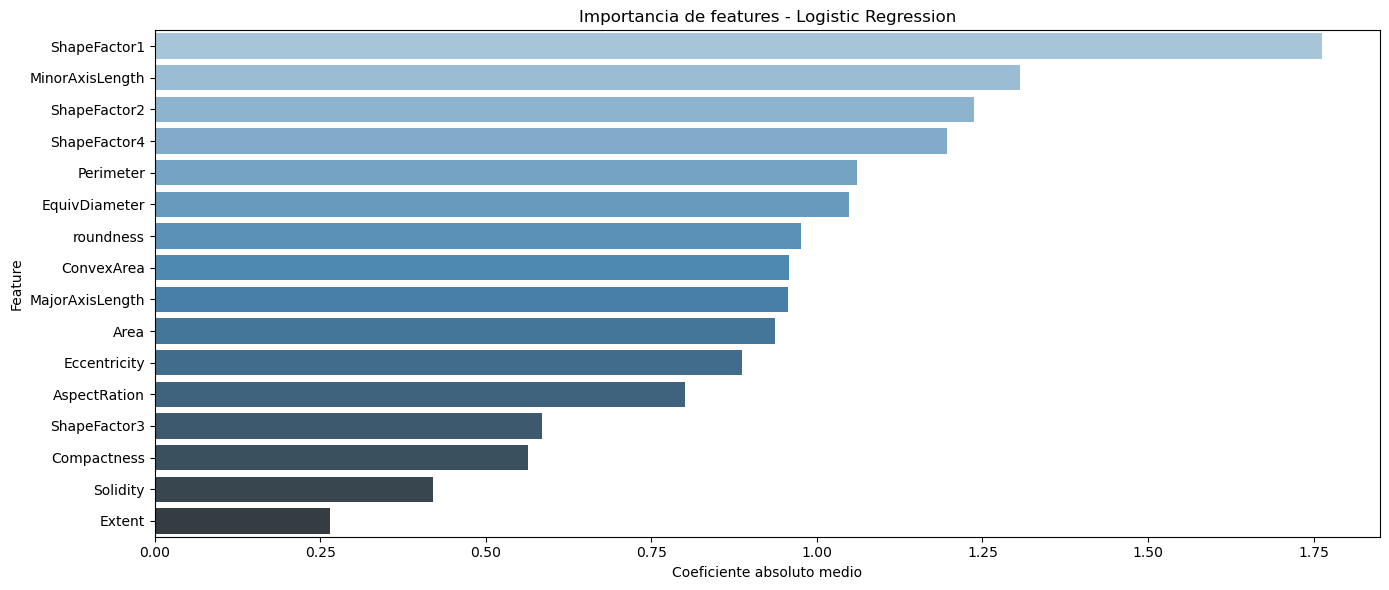

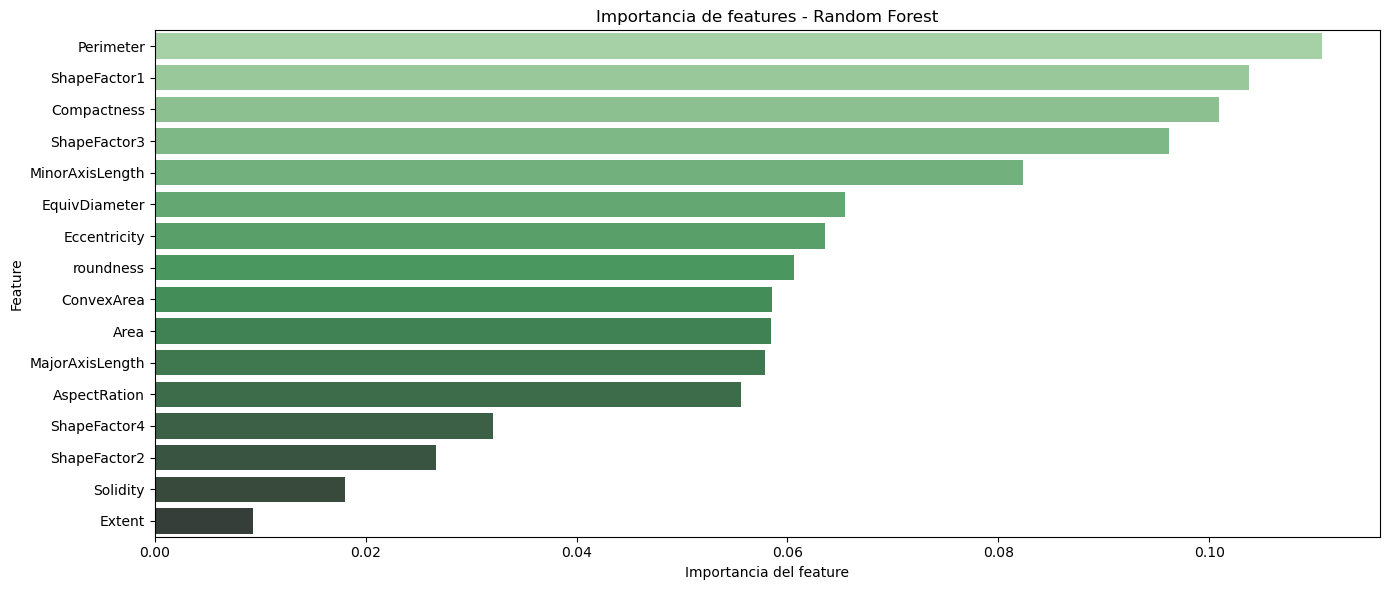

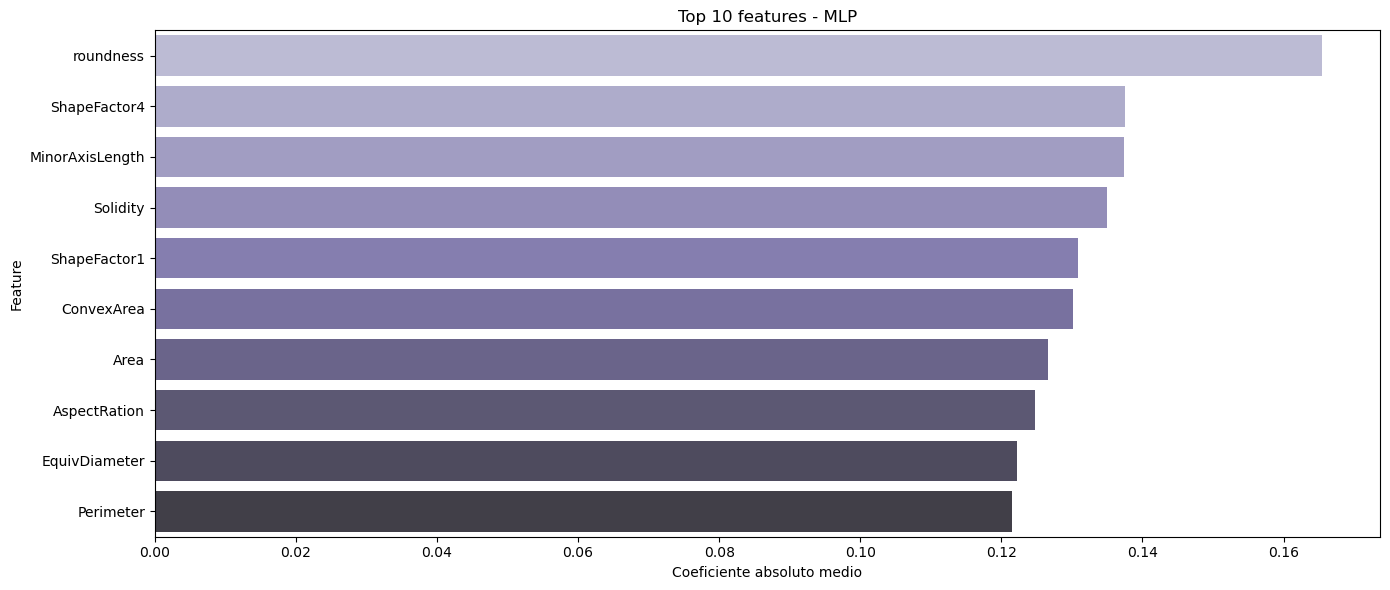

Top 10 Logistic Regression
            feature  importance
12     ShapeFactor1    1.762288
3   MinorAxisLength    1.306633
13     ShapeFactor2    1.236723
15     ShapeFactor4    1.195814
1         Perimeter    1.061153
7     EquivDiameter    1.048376
10        roundness    0.976702
6        ConvexArea    0.957632
2   MajorAxisLength    0.956463
0              Area    0.936185

Top 10 Random Forest
            feature  importance
1         Perimeter    0.110657
12     ShapeFactor1    0.103784
11      Compactness    0.100960
14     ShapeFactor3    0.096224
3   MinorAxisLength    0.082303
7     EquivDiameter    0.065410
5      Eccentricity    0.063603
10        roundness    0.060583
6        ConvexArea    0.058514
0              Area    0.058437

Top 10 MLP
            feature  importance
10        roundness    0.165401
15     ShapeFactor4    0.137575
3   MinorAxisLength    0.137422
9          Solidity    0.134947
12     ShapeFactor1    0.130924
6        ConvexArea    0.130188
0          

In [14]:
import numpy as np
import seaborn as sns
lr_coefs = np.mean(np.abs(baseline_model.named_steps["classifier"].coef_), axis=0)

importance_lr = pd.DataFrame({
    "feature": X.columns,
    "importance": lr_coefs
}).sort_values("importance", ascending=False)

importance_rf = pd.DataFrame({
    "feature": X.columns,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_MLP = pd.DataFrame({
    "feature": X.columns,
    "importance": np.mean(np.abs(mlp_model.coefs_[0]), axis=1)
}).sort_values("importance", ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_lr, x="importance", y="feature", palette="Blues_d")
plt.title("Importancia de features - Logistic Regression")
plt.xlabel("Coeficiente absoluto medio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_rf, x="importance", y="feature", palette="Greens_d")
plt.title("Importancia de features - Random Forest")
plt.xlabel("Importancia del feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(data=importance_MLP.head(10), x="importance", y="feature", palette="Purples_d")
plt.title("Top 10 features - MLP")
plt.xlabel("Coeficiente absoluto medio")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 10 Logistic Regression")
print(importance_lr.head(10))

print("\nTop 10 Random Forest")
print(importance_rf.head(10))

print("\nTop 10 MLP")
print(importance_MLP.head(10))

# Guardar Modelos

In [ ]:
import joblib
joblib.dump(baseline_model, r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\outputs\models\reports\baseline_model.joblib")
joblib.dump(forest_model, r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\outputs\models\reports\random_forest_model.joblib")
joblib.dump(mlp_model, r"C:\UAO\Gestion IA y DC\laboratorio_drybean_ml\outputs\models\reports\mlp_model.joblib")

['C:\\UAO\\Gestion IA y DC\\laboratorio_drybean_ml\\outputs\\models\\reports\\random_forest_model.joblib']